## Creating Lo-Fi data for small/large amplitude oscillatory shear (S/LAOS) rheometry
In this notebook, the synthetic generation of Lo-Fi data is introduced based on the given Hi-Fi data. This is a more intricate one as we need to introduce some form of physics to generate the Lo-Fi data.

<img src="../LoFi_LAOS.jpg" alt="MFNN architecture" width="600"/>

First of all, we need to extract the time shift for each S/LAOS test. Note that the given data is in sheets. For each sheet in `Data_HF_SAOS_raw.xlsx`, we need to extract the shifted time, maxietam strain, angular frequency, stress, strain, and strain rate, respectively, by calling the `extractor()` function.


### Importing dependencies

In [10]:
import numpy as np
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from scipy.optimize import curve_fit
from scipy.integrate import odeint
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor  # Import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

In [11]:
np.set_printoptions(suppress=True)
path = os.getcwd()
files = os.listdir(path)
df = {}
# url = 'https://github.com/procf/RhINNs/raw/main/MFNN/SAOS/Data_HF_SAOS_raw.xlsx'
#Uncomment the below line to run locally
url = pd.ExcelFile(r"C:\Users\alanh\PunLab\mfnn\experiments\Pigs_NegCon\combined_pig_negcon.xlsx")

df = pd.read_excel(url, sheet_name=None)
data = [[k,v] for k,v in df.items()]
t_train, g_train, w_train = np.array([]), np.array([]), np.array([])
s_train = np.array([])

def pos_finder(vector):
    vector = np.array(vector)
    for i in range(len(vector) - 1):
        if vector[i] < 0 and vector[i + 1] >= 0:
            return i + 1
    return -1
    
def extractor(i):
    data[i][1] = data[i][1].dropna()
    print(data[i][0])
    
    #handling the time shift
    ind = pos_finder(data[i][1]['Strain'])
    t0 = data[i][1]['Step time'].iloc[ind]
    ymax = data[i][1]['Stress'].iloc[ind]
    
    #column extraction 
    St = data[i][1]['Strain']
    SR = data[i][1]['Shear rate']
    Time = data[i][1]['Step time']
    w = data[i][1]['Angular frequency']
    G0 = data[i][1]['Oscillation strain'] * 100
    Stress = data[i][1]['Stress']
    Time_adj = Time - t0
    Time_adj = Time_adj
    return Time_adj, G0, w, Stress, St, SR

### Extracting $\tau$ and $\eta$
Then, you need to run the following cell for all sheets in `Data_HF_SAOS_raw.xlsx`. For each sheet, we fit a single-mode Maxwell VE model and extract $\tau$ and $\eta$ as a function of $\gamma_0$, $\omega$, and $t$. Note that we are using the `odeint` package, which is an ODE solver. Similar to other ODE solvers, we need initial condition (`y0`), `initial_guess`, and `bounds`. For each sheet, an appropriate `y0` is needed. For this particular sheet, `y0` is 90 Pa.

For this sheet, $\tau$ and $\eta$ are 0.16183 and0.14525, respectively. We do the same thing for all stress curves to obtain the following table:

--- Processing Sheet 0: 0.628rad - 7.19e-05 ---
0.628rad - 7.19e-05


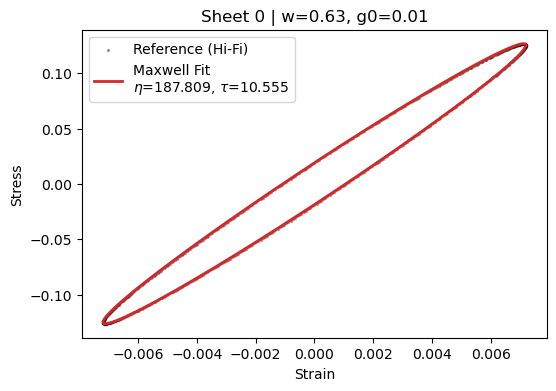

--- Processing Sheet 1: 0.628rad - 0.0002555 ---
0.628rad - 0.0002555


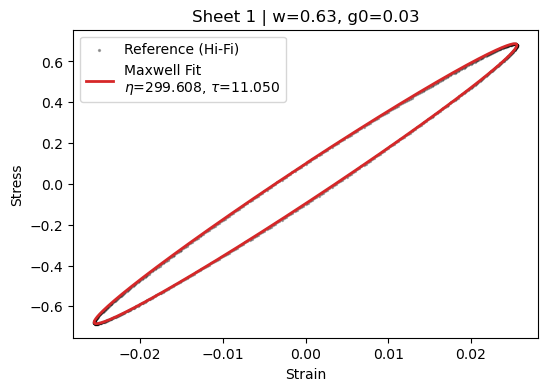

--- Processing Sheet 2: 0.628rad - 0.0008726 ---
0.628rad - 0.0008726


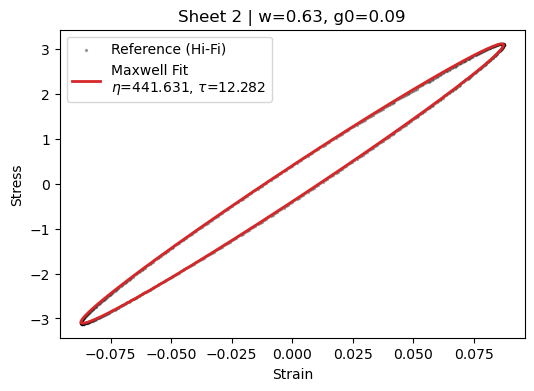

--- Processing Sheet 3: 0.628rad - 0.0027413 ---
0.628rad - 0.0027413


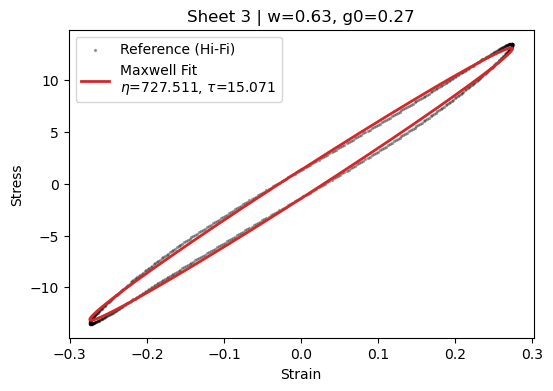

--- Processing Sheet 4: 0.628rad - 0.0073965 ---
0.628rad - 0.0073965


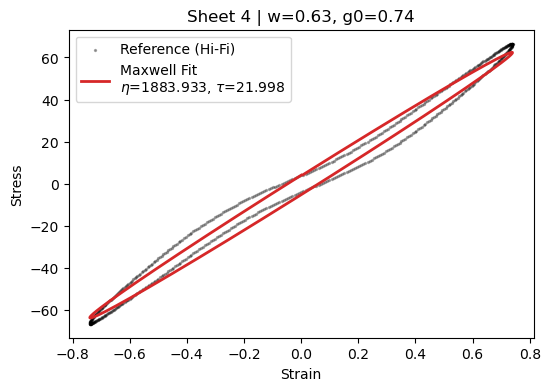

--- Processing Sheet 5: 0.628rad - 0.0235937 ---
0.628rad - 0.0235937


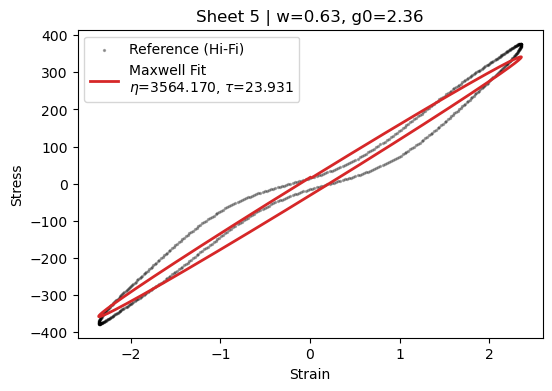

--- Processing Sheet 6: 0.628rad - 7.46e-05 ---
0.628rad - 7.46e-05


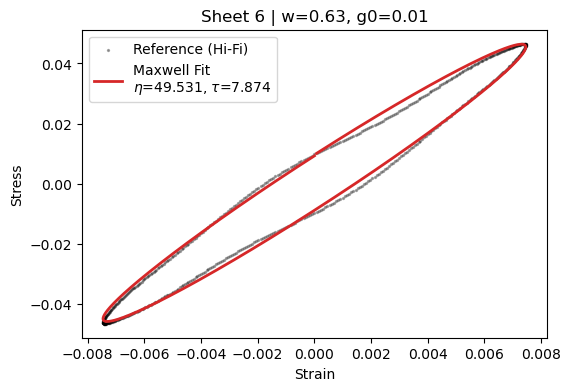

--- Processing Sheet 7: 0.628rad - 0.0002212 ---
0.628rad - 0.0002212


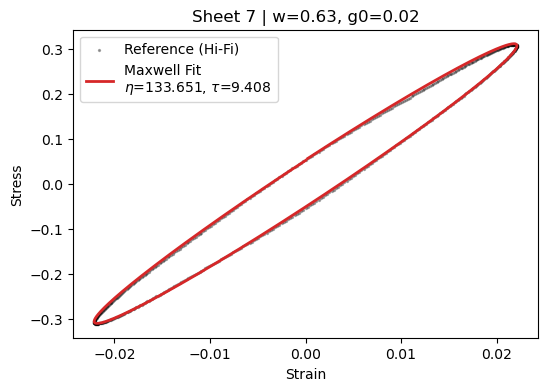

--- Processing Sheet 8: 0.628rad - 0.0007927 ---
0.628rad - 0.0007927


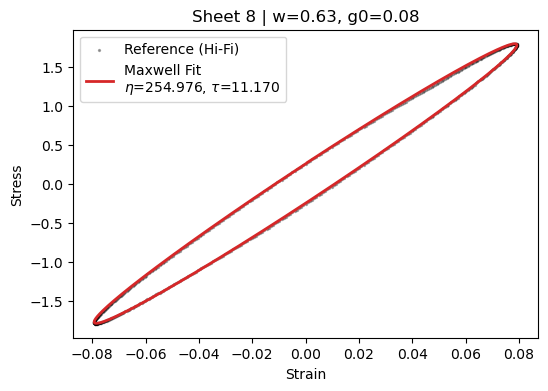

--- Processing Sheet 9: 0.628rad - 0.0026243 ---
0.628rad - 0.0026243


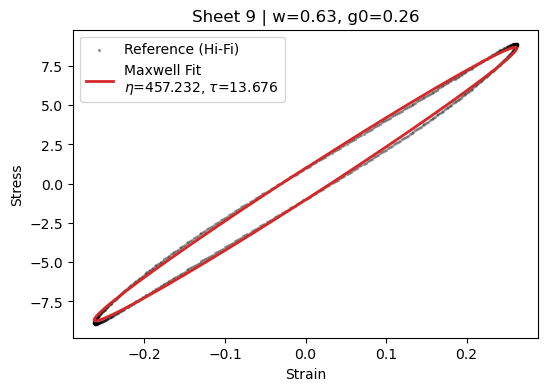

--- Processing Sheet 10: 0.628rad - 0.0072428 ---
0.628rad - 0.0072428


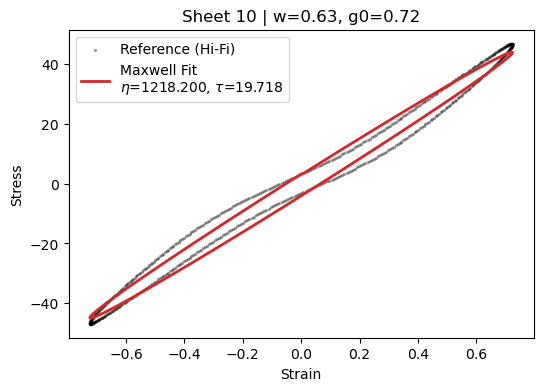

--- Processing Sheet 11: 0.628rad - 0.036871 ---
0.628rad - 0.036871


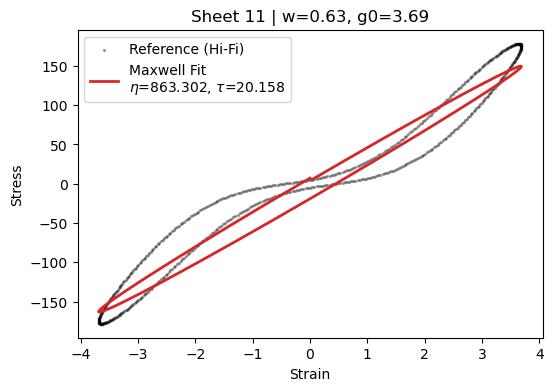

--- Processing Sheet 12: 0.628rad - 7.76e-05 ---
0.628rad - 7.76e-05


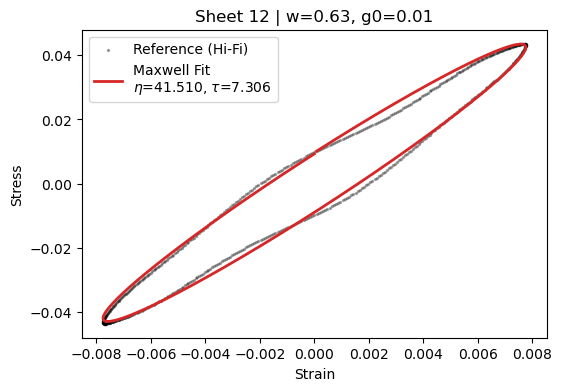

--- Processing Sheet 13: 0.628rad - 0.000234 ---
0.628rad - 0.000234


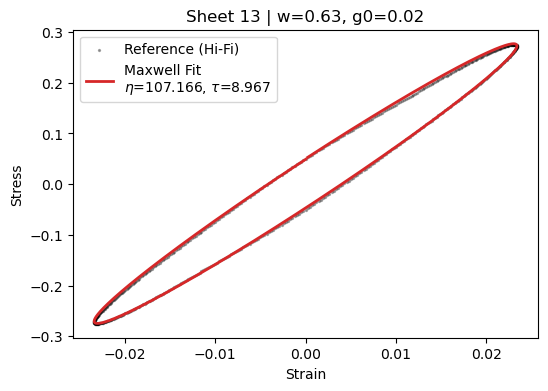

--- Processing Sheet 14: 0.628rad - 0.0008087 ---
0.628rad - 0.0008087


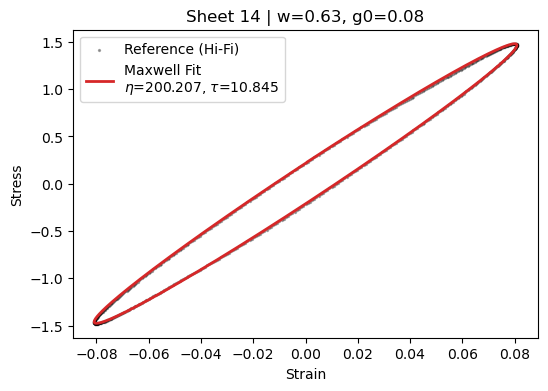

--- Processing Sheet 15: 0.628rad - 0.002616 ---
0.628rad - 0.002616


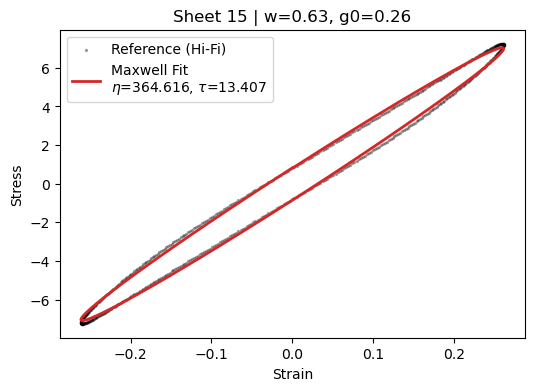

--- Processing Sheet 16: 0.628rad - 0.0069447 ---
0.628rad - 0.0069447


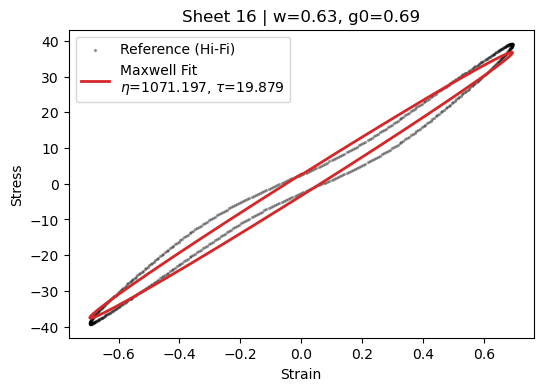

--- Processing Sheet 17: 0.628rad - 0.0303729 ---
0.628rad - 0.0303729


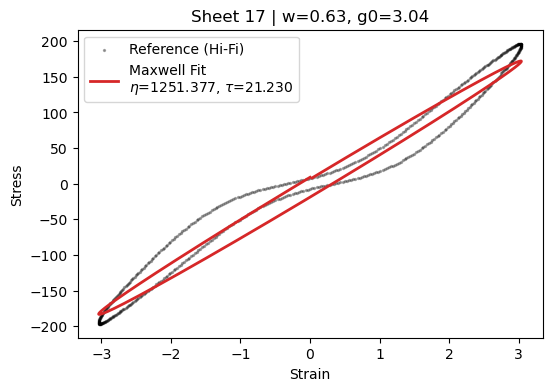

--- Processing Sheet 18: 0.628rad - 6.77e-05 ---
0.628rad - 6.77e-05


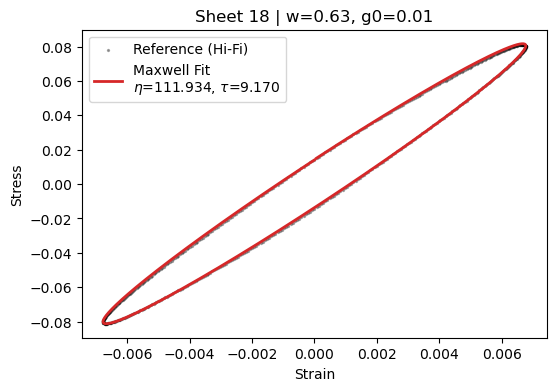

--- Processing Sheet 19: 0.628rad - 0.0002321 ---
0.628rad - 0.0002321


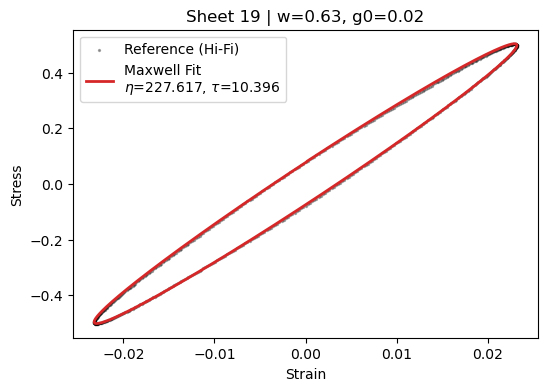

--- Processing Sheet 20: 0.628rad - 0.000835 ---
0.628rad - 0.000835


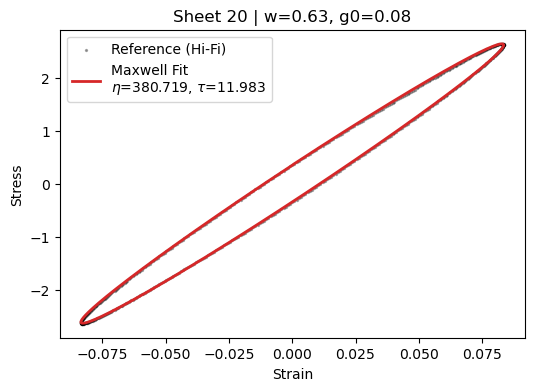

--- Processing Sheet 21: 0.628rad - 0.0027183 ---
0.628rad - 0.0027183


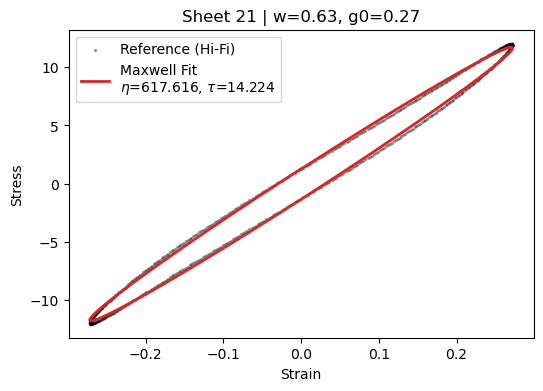

--- Processing Sheet 22: 0.628rad - 0.0079461 ---
0.628rad - 0.0079461


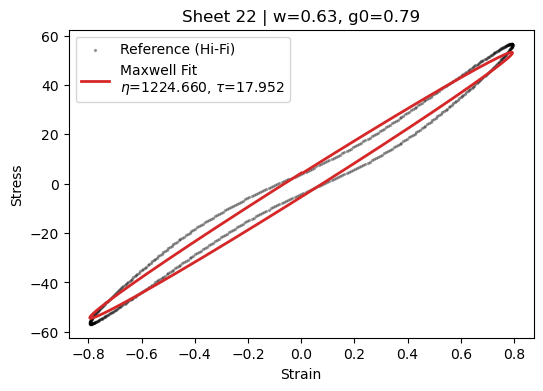

--- Processing Sheet 23: 0.628rad - 0.0583731 ---
0.628rad - 0.0583731


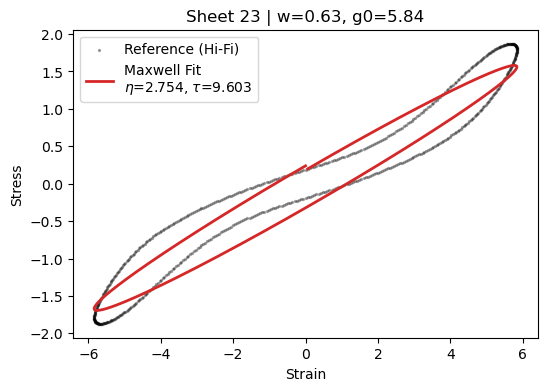

--- Processing Sheet 24: 0.628rad - 7.83e-05 ---
0.628rad - 7.83e-05


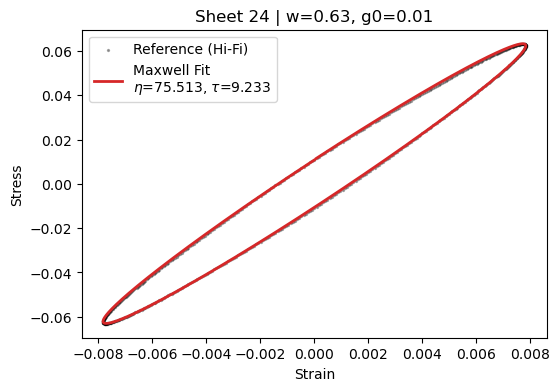

--- Processing Sheet 25: 0.628rad - 0.0002521 ---
0.628rad - 0.0002521


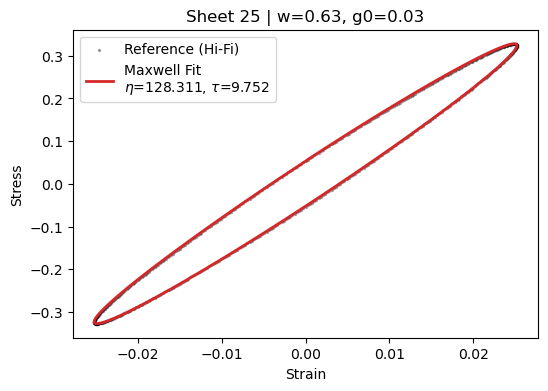

--- Processing Sheet 26: 0.628rad - 0.0008682 ---
0.628rad - 0.0008682


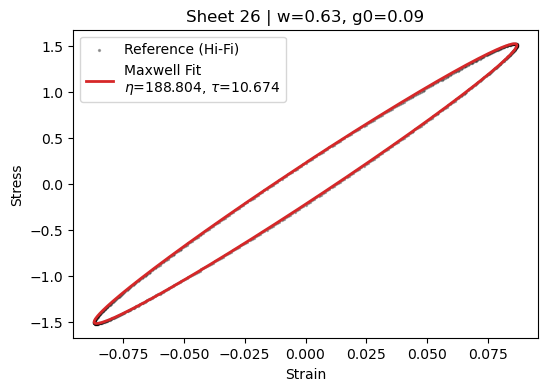

--- Processing Sheet 27: 0.628rad - 0.0027884 ---
0.628rad - 0.0027884


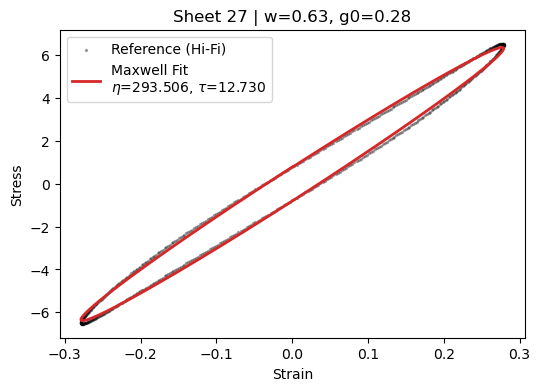

--- Processing Sheet 28: 0.628rad - 0.0075938 ---
0.628rad - 0.0075938


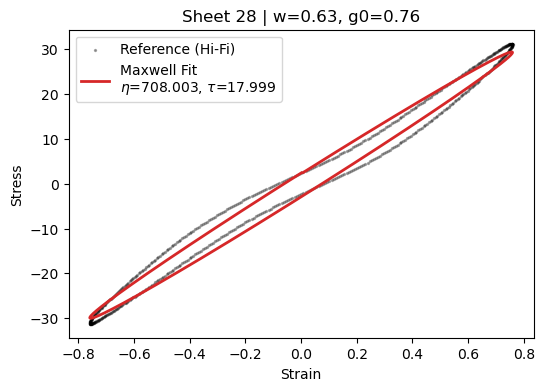

--- Processing Sheet 29: 0.628rad - 0.041893 ---
0.628rad - 0.041893


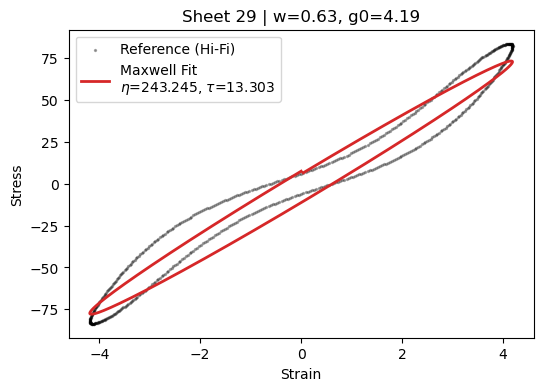


y_fit (eta, tau):
array([[ 187.80916937,   10.55508625],
       [ 299.60833683,   11.04950862],
       [ 441.63129611,   12.28179702],
       [ 727.51133254,   15.07051102],
       [1883.93300453,   21.99803549],
       [3564.16981879,   23.9310672 ],
       [  49.53070623,    7.87407857],
       [ 133.65127335,    9.40806145],
       [ 254.97583102,   11.17026877],
       [ 457.23186411,   13.67599862],
       [1218.20026166,   19.71821702],
       [ 863.30229759,   20.1580422 ],
       [  41.51010798,    7.30610892],
       [ 107.16590898,    8.96699923],
       [ 200.2065264 ,   10.84523421],
       [ 364.61621812,   13.40706067],
       [1071.19747045,   19.87887572],
       [1251.37650394,   21.22990666],
       [ 111.9336165 ,    9.16962369],
       [ 227.61655406,   10.39598565],
       [ 380.71946955,   11.98336032],
       [ 617.61558591,   14.22397104],
       [1224.66043813,   17.95234287],
       [   2.75407855,    9.6028694 ],
       [  75.51280627,    9.23310826],
      

In [12]:
# Initialize lists to store the results from all sheets
y_fit_list = []
x_fit_list = []
y0_fit_list = []

# Define the ODE function (relies on global g0, omega, which we update in the loop)
def maxwell_ve(y, t, eta, tau):
    gdot = g0 * omega * np.cos(omega * t * tmax * wmax)
    dydt = (1.0 / tau) * (eta * gdot - y)
    return dydt

def fit_function(t, eta, tau):
    # Solves ODE using the current global y0
    y_pred = odeint(maxwell_ve, y0, t, args=(eta, tau))
    return y_pred[:, 0]

# --- Main Loop over all Data Sheets ---
for i in range(len(data)):
    print(f"--- Processing Sheet {i}: {data[i][0]} ---")
    
    # 1. Extract data for this specific sheet
    t_train, g_train, w_train, s_train, st_train, sr_train = extractor(i)
    
    # 2. normalization settings
    Norm = False
    if Norm:
        tmax = 5.7835
        gmax = 1000.
        wmax = 10.
        smax = 216.73
        t_train, g_train, w_train, s_train = t_train/tmax, g_train/gmax, w_train/wmax, s_train/smax
    else:
        tmax = 1.
        gmax = 1.
        wmax = 1.
        smax = 1.

    # 3. Update Global Variables for the ODE solver
    # We take the unique scalar values for Amplitude (g0) and Frequency (omega)
    # We take the first stress point as the initial condition (y0)
    g0 = np.unique(g_train)[0]
    omega = np.unique(w_train)[0]
    y0 = s_train.iloc[0] if hasattr(s_train, 'iloc') else s_train[0]
    
    # Setup fitting vectors
    t = t_train
    y = s_train
    g = g0 * np.sin(omega * t_train * tmax * wmax) # Theoretical strain for plotting
    
    # 4. Perform the Fit
    initial_guess = [0.1, 0.2]  # Generic initial guess
    bounds = ([0.0, 0.0], [np.inf, np.inf])
    
    try:
        fit_params, covariance = curve_fit(fit_function, t, y,
                                           p0=initial_guess,
                                           bounds=bounds,
                                           method='trf',
                                           maxfev=5000)
        eta_fit, tau_fit = fit_params
    except RuntimeError:
        print(f"Fit failed for sheet {i}. Using zeros.")
        eta_fit, tau_fit = 0.0, 0.0

    # 5. Append results to lists
    # y_fit stores [eta, tau]
    y_fit_list.append([eta_fit, tau_fit])
    # x_fit stores [omega, g0]
    x_fit_list.append([omega, g0])
    # y0_fit stores the initial stress
    y0_fit_list.append(y0)

    # 6. Plot the result for visual verification
    y_predicted = fit_function(t, eta_fit, tau_fit)
    
    plt.figure(figsize=(6, 4))
    plt.title(f"Sheet {i} | w={omega:.2f}, g0={g0:.2f}")
    plt.scatter(g, y, label='Reference (Hi-Fi)', s=2, color='k', alpha=0.3)
    plt.plot(g, y_predicted, '-', label=f'Maxwell Fit\n$\eta$={eta_fit:.3f}, $\\tau$={tau_fit:.3f}', linewidth=2, color='tab:red')
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.legend()
    plt.show()

# --- Convert lists to numpy arrays for the next steps ---
y_fit = np.array(y_fit_list)
x_fit = np.array(x_fit_list)
y0_fit = np.array(y0_fit_list)

print("\ny_fit (eta, tau):")
print(repr(y_fit))
print("\nx_fit (omega, g0):")
print(repr(x_fit))
print("\ny0_fit (initial stress):")
print(repr(y0_fit))

In [13]:
# #The entire fitting parameters
# y_fit = np.array([[ 1.3018589 ,  6.88171745],
#        [ 2.81325174, 10.19232574],
#        [ 3.53696276,  9.6563423 ],
#        [ 6.54552896, 13.53587704],
#        [21.35111473, 25.29370299],
#        [50.09332498, 34.29473828]])

# x_fit = np.array([[  0.628319,   0.597749],
#        [  0.628319,   2.06854 ],
#        [  0.628319,   8.00354 ],
#        [  0.628319,  26.537   ],
#        [  0.628319,  75.4325  ],
#        [  0.628319, 357.178   ]])
# y0_fit = np.array([ -0.0186151,   0.100272 ,   1.438    ,   9.25357  ,  55.5056   ,
#        273.898    ])

### Masking Hi-Fi data
Here, and depending on which stress loop we wish to omit from MFNN training, we select from `hf_set`.

In [14]:
# 1. Use train_test_split to create a 20% "masking" set
# 'indices' will allow us to map back to y_fit and y0_fit easily
indices = np.arange(len(x_fit))
idx_remaining, idx_masked = train_test_split(indices, test_size=0.20, random_state=42)

# 2. Extract the data based on the split
x_max = x_fit[idx_remaining]
y_max = y_fit[idx_remaining]
y_00  = y0_fit[idx_remaining]

# 3. Identify the masked set (the 20% we set aside)
diff = x_fit[idx_masked]

print(f'Total points: {len(x_fit)}')
print(f'Masked points: {len(diff)}')
print('\nThe masked set(s) are:\n', diff)

Total points: 30
Masked points: 6

The masked set(s) are:
 [[0.628   0.27884]
 [0.628   0.2616 ]
 [0.628   5.83731]
 [0.628   3.03729]
 [0.628   0.07927]
 [0.628   0.26243]]


### Regression of $\tau$ and $\eta$ on $\gamma_0$ and $\omega$

Here, we have several options to select the regression kernel. The output of this cell is the regressed $\tau$ and $\eta$ values for each kernel.

In [15]:
poly_regressor = make_pipeline(PolynomialFeatures(degree=2), MultiOutputRegressor(LinearRegression()))
poly_regressor.fit(x_max, y_max)
poly_predictions = poly_regressor.predict(x_max)
rf_regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
rf_regressor.fit(x_max, y_max)
rf_predictions = rf_regressor.predict(x_max)
mlp_regressor = MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20),
                                                  max_iter=10000,
                                                  random_state=4,
                                                  solver='lbfgs',
                                                 activation='tanh',
                                                 alpha=1e-3))
mlp_regressor.fit(x_max, y_max)
mlp_predictions = mlp_regressor.predict(x_max)

print("Second-Order Polynomial Regression Predictions:")
print(poly_predictions)

print("\nRandom Forest Regression Predictions:")
print(rf_predictions)

print("\nMLP Regression Predictions:")
print(mlp_predictions)

Second-Order Polynomial Regression Predictions:
[[1539.68548352   19.17747069]
 [  63.09867778    9.78471142]
 [  62.93158679    9.78365792]
 [  61.57078377    9.77507814]
 [1509.03385697   18.97991689]
 [1437.19659452   18.51757758]
 [2569.32156253   26.39806891]
 [ 100.1276709    10.01821412]
 [1239.74425971   19.19043724]
 [1593.32933928   19.52364914]
 [ 105.2194537    10.05032823]
 [ 249.15135151   10.95869616]
 [ 104.41458729   10.04525181]
 [ 658.90661172   13.55167862]
 [ 654.10184349   13.52120562]
 [ 248.14024572   10.95231093]
 [  60.5678532     9.76875478]
 [ 220.51730573   13.34367756]
 [ 240.50397936   10.90408904]
 [  97.09381722    9.99908012]
 [1484.85262041   18.82418728]
 [ 234.44597637   10.86583604]
 [  99.67744961   10.01537462]
 [  62.21542018    9.77914252]]

Random Forest Regression Predictions:
[[1095.80560403   19.25735183]
 [  63.16017009    8.44696418]
 [  52.27930664    7.83032439]
 [ 136.34943455    9.54062489]
 [1667.84316629   21.27528108]
 [1171.211018

c:\Users\alanh\PunLab\mfnn\.pixi\envs\default\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


### Hi-Fi data extraction and sampling
Since we used the raw Hi-Fi data, we need to extract those shifted Hi-Fi data and use them for MFNN training. Also, the given Hi-Fi data was too dense, and we sample every 40 of them.

In [19]:
hf_set = idx_remaining

print(f"Training on {len(hf_set)} samples. Masking {len(idx_masked)} samples.")
print(f"Masked Indices: {idx_masked}")

# Initialize arrays
g0_hf, t_hf, w_hf = np.array([]), np.array([]), np.array([])
g_hf, gdot_hf, s_hf = np.array([]), np.array([]), np.array([])

# Loop over the training set (hf_set) only
for i in hf_set:
    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)
    
    g0_hf = np.append(g0_hf, g0_test)
    t_hf = np.append(t_hf, t_test)
    w_hf = np.append(w_hf, w_test)
    
    g_hf = np.append(g_hf, st_test)
    gdot_hf = np.append(gdot_hf, sr_test)
    s_hf = np.append(s_hf, s_test)

# Downsampling (unchanged logic)
sampled_indices = np.arange(0, len(t_hf), 40)

t_hf_sampled = t_hf[sampled_indices]
g0_hf_sampled = g0_hf[sampled_indices]
w_hf_sampled = w_hf[sampled_indices]
g_hf_sampled = g_hf[sampled_indices]
gdot_hf_sampled = gdot_hf[sampled_indices]
s_hf_sampled = s_hf[sampled_indices]

print(f"Final sampled data points: {len(s_hf_sampled)}")

Training on 24 samples. Masking 6 samples.
Masked Indices: [27 15 23 17  8  9]
0.628rad - 0.0075938
0.628rad - 7.83e-05
0.628rad - 7.76e-05
0.628rad - 7.19e-05
0.628rad - 0.0073965
0.628rad - 0.0069447
0.628rad - 0.0235937
0.628rad - 0.000234
0.628rad - 0.036871
0.628rad - 0.0079461
0.628rad - 0.0002555
0.628rad - 0.0008726
0.628rad - 0.0002521
0.628rad - 0.0027413
0.628rad - 0.0027183
0.628rad - 0.0008682
0.628rad - 6.77e-05
0.628rad - 0.041893
0.628rad - 0.000835
0.628rad - 0.0002212
0.628rad - 0.0072428
0.628rad - 0.0008087
0.628rad - 0.0002321
0.628rad - 7.46e-05
Final sampled data points: 366


Almost there. Now, for each set in `lf_set`, which is essentially all the loops, we call the `fit_function()` function, which predicts the linear VE stress response as a function of `t_pred`, `eta_pred`, and `tau_pred`. We then append every variable to an empty vector, and call that our Lo-Fi data. Keeping an eye on the top image as reference can also help. :)

0.628rad - 7.19e-05


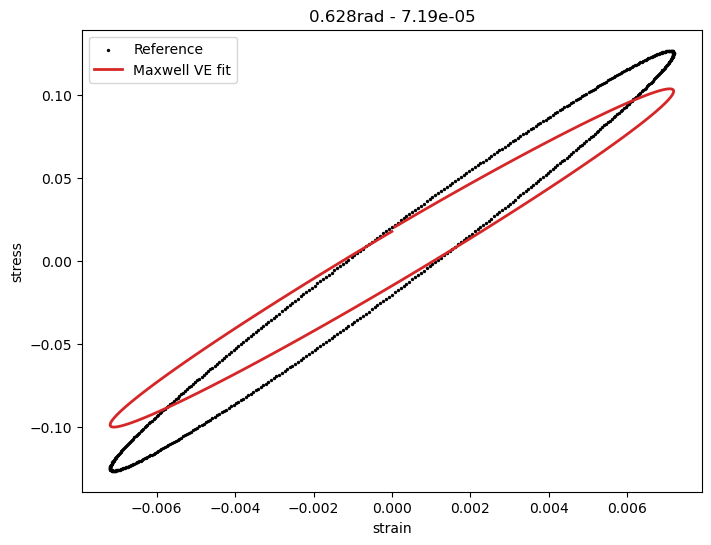

0.628rad - 0.0002555


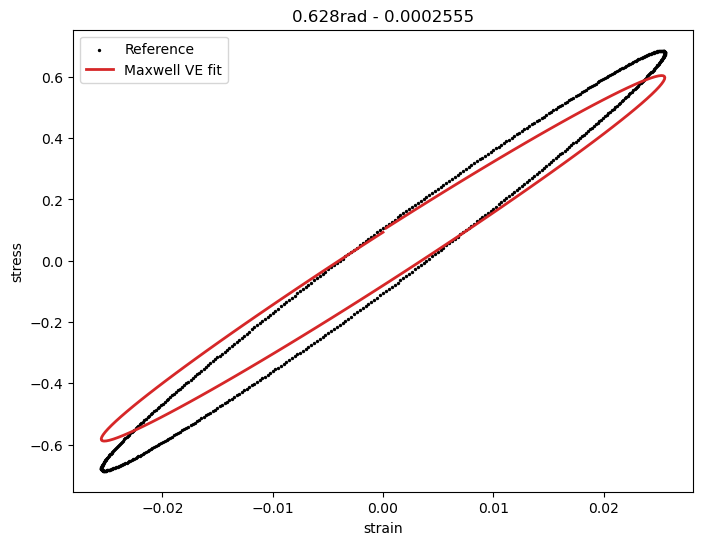

0.628rad - 0.0008726


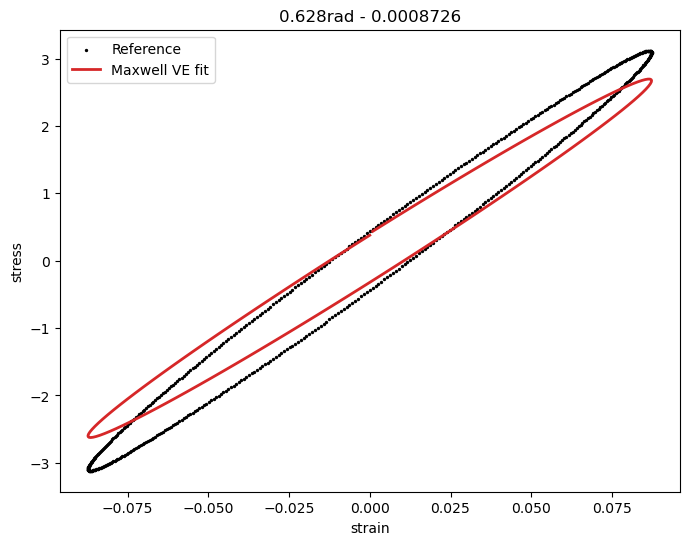

0.628rad - 0.0027413


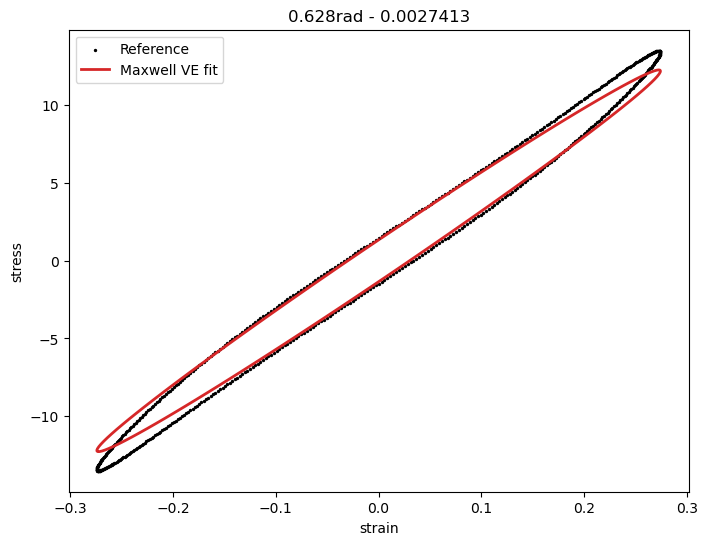

0.628rad - 0.0073965


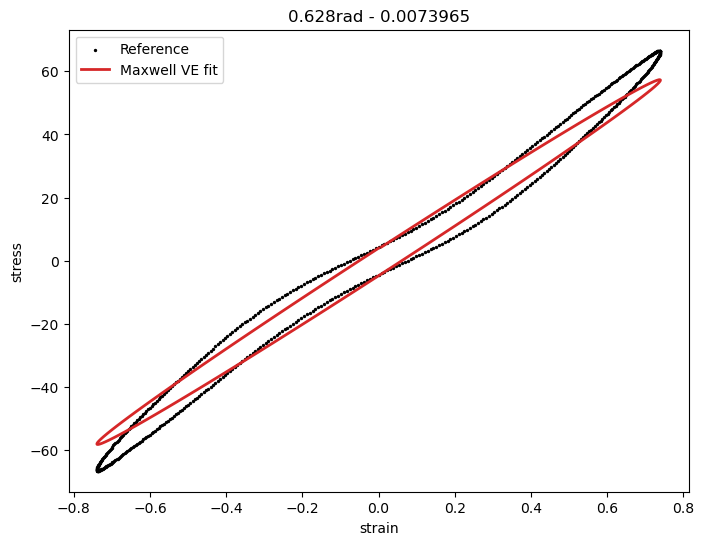

0.628rad - 0.0235937


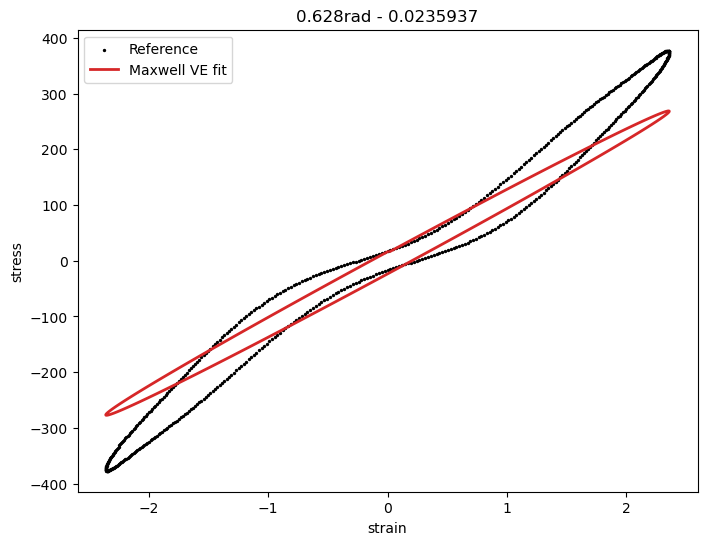

0.628rad - 7.46e-05


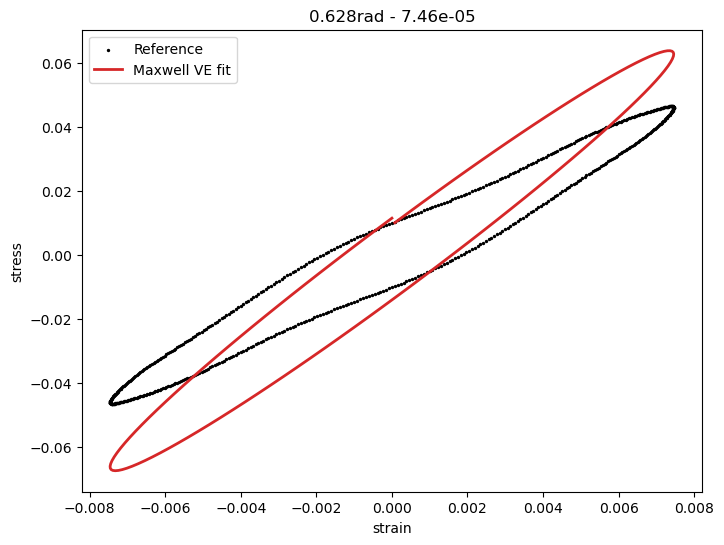

0.628rad - 0.0002212


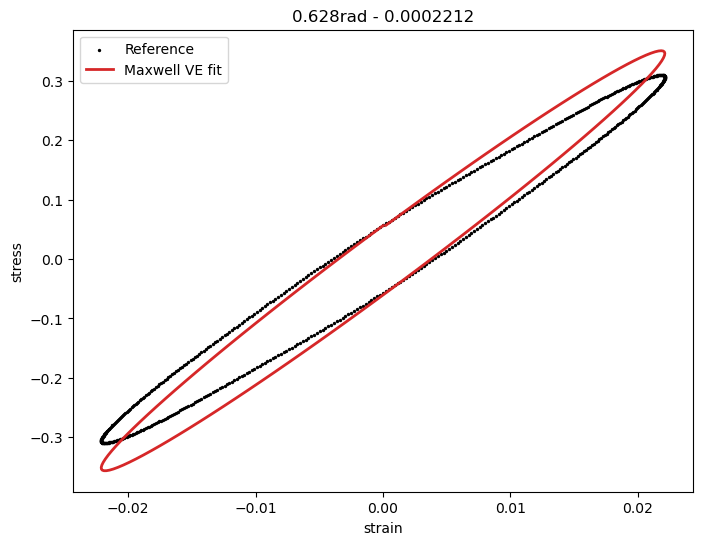

0.628rad - 0.0007927


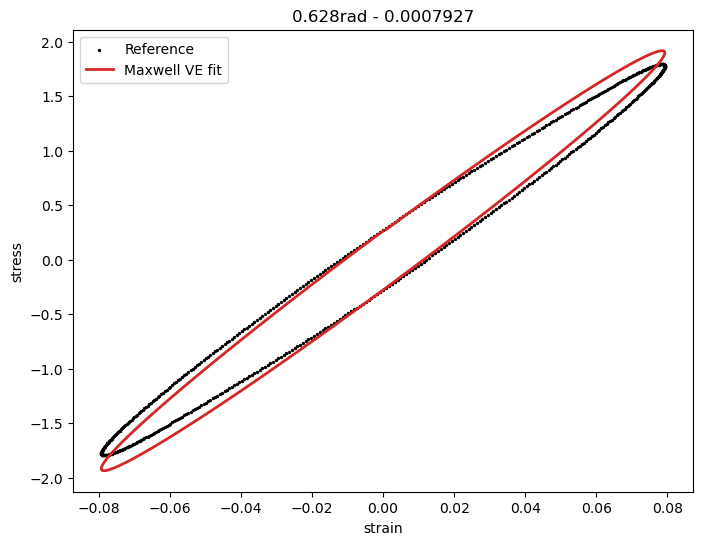

0.628rad - 0.0026243


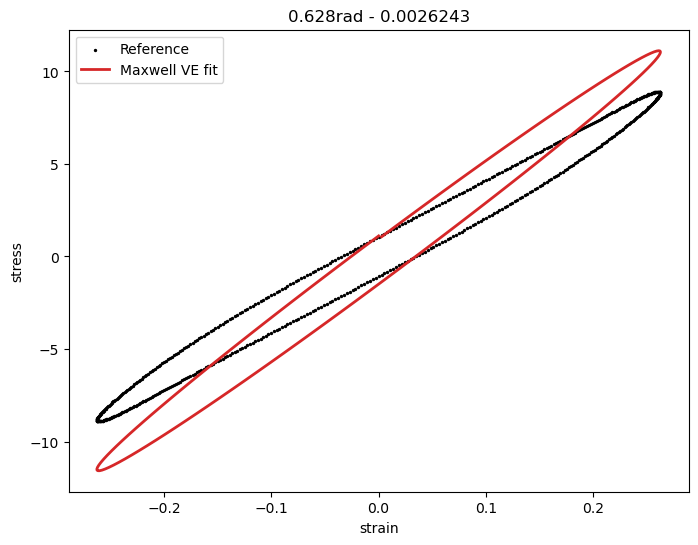

0.628rad - 0.0072428


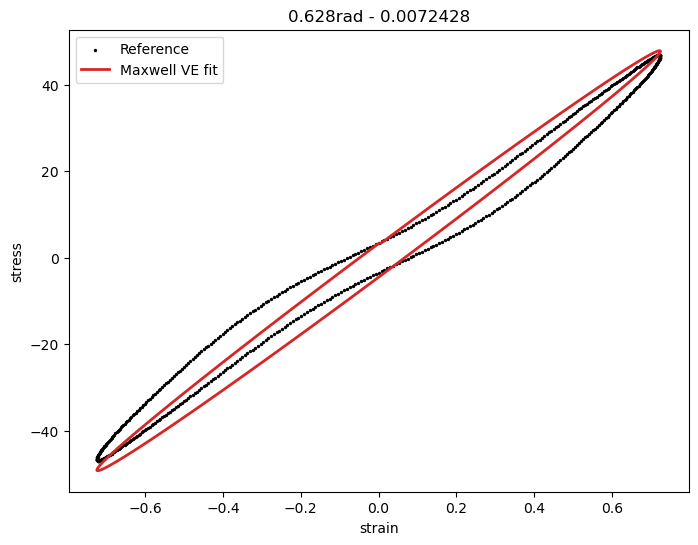

0.628rad - 0.036871


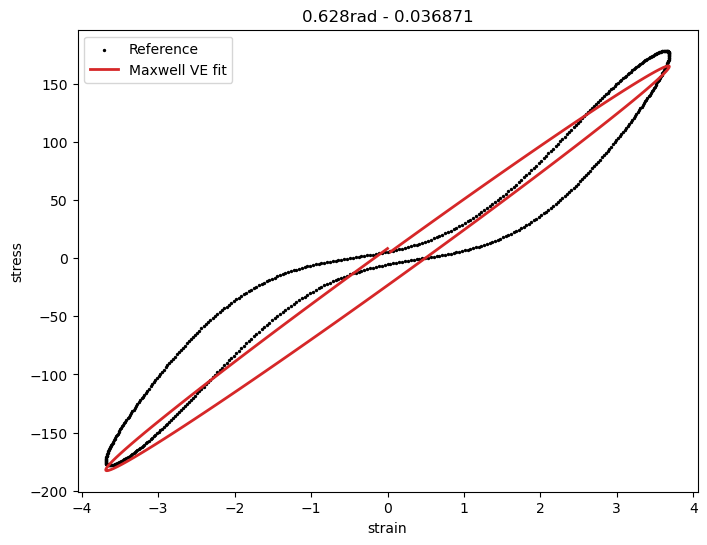

0.628rad - 7.76e-05


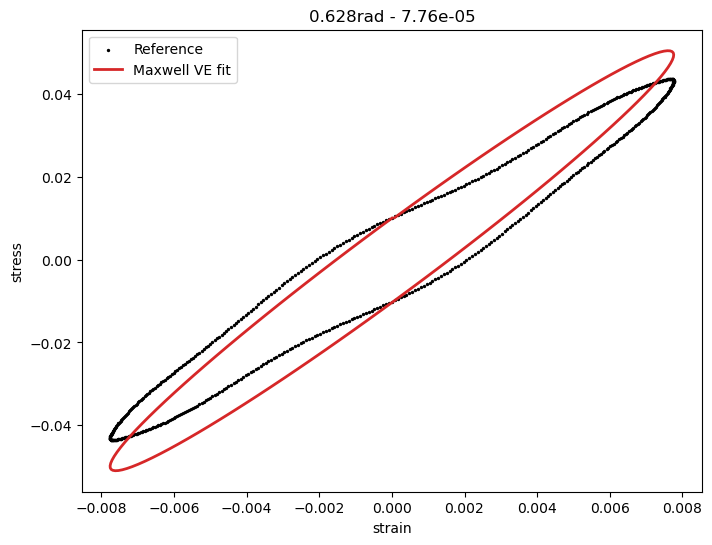

0.628rad - 0.000234


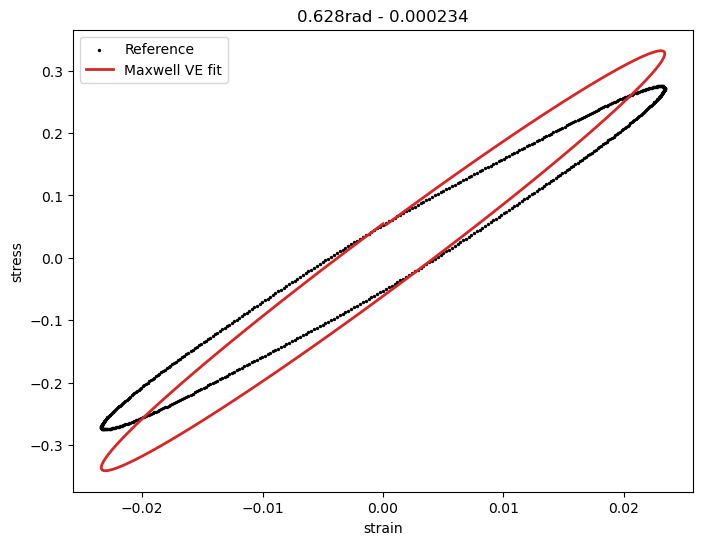

0.628rad - 0.0008087


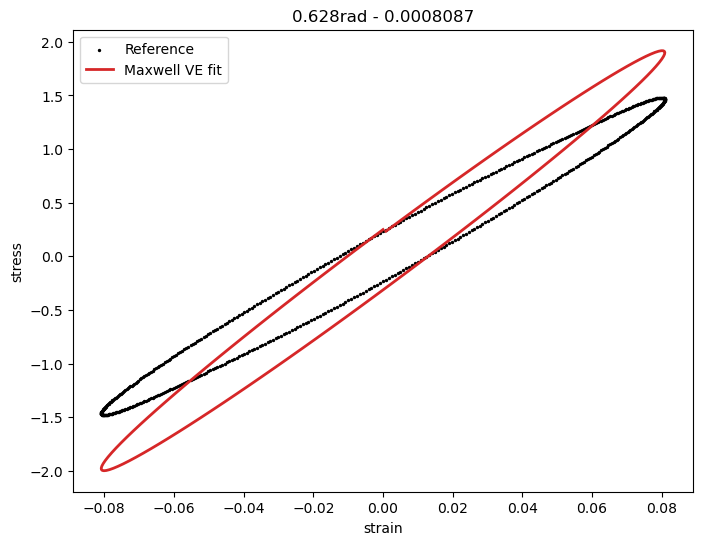

0.628rad - 0.002616


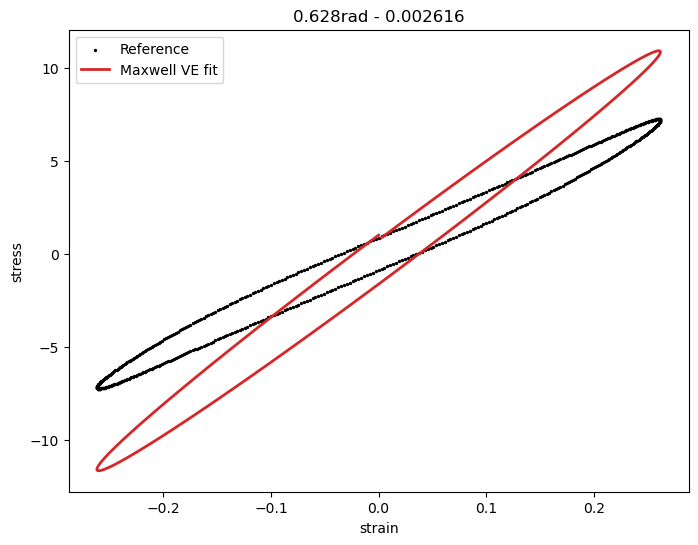

0.628rad - 0.0069447


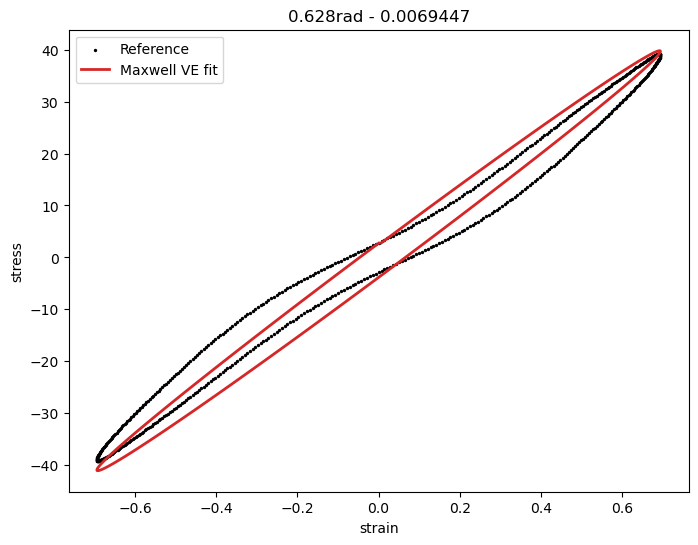

0.628rad - 0.0303729


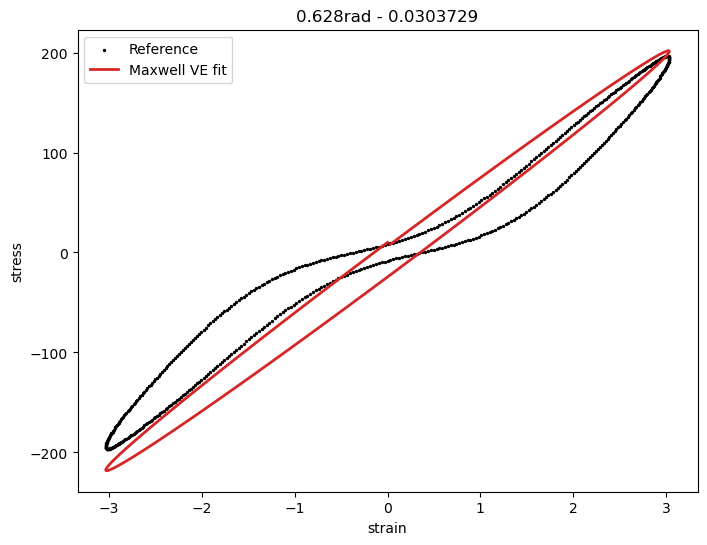

0.628rad - 6.77e-05


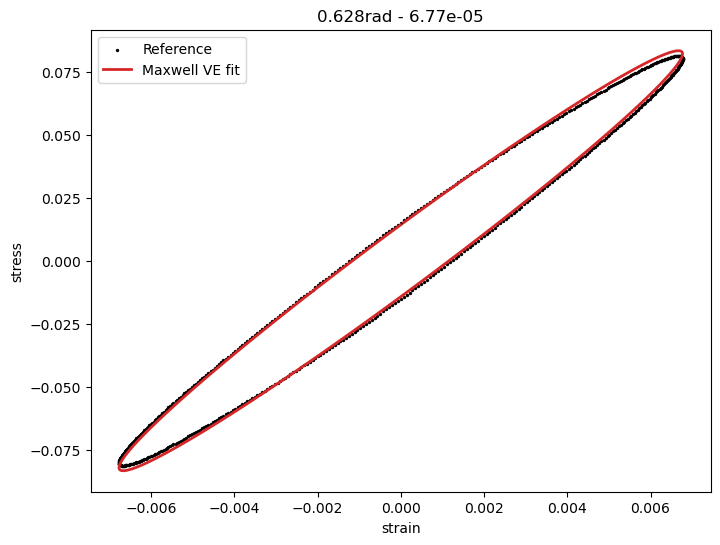

0.628rad - 0.0002321


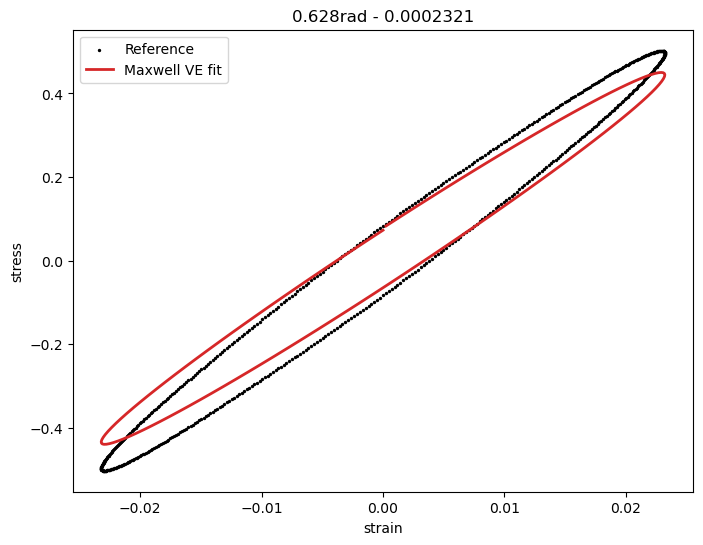

0.628rad - 0.000835


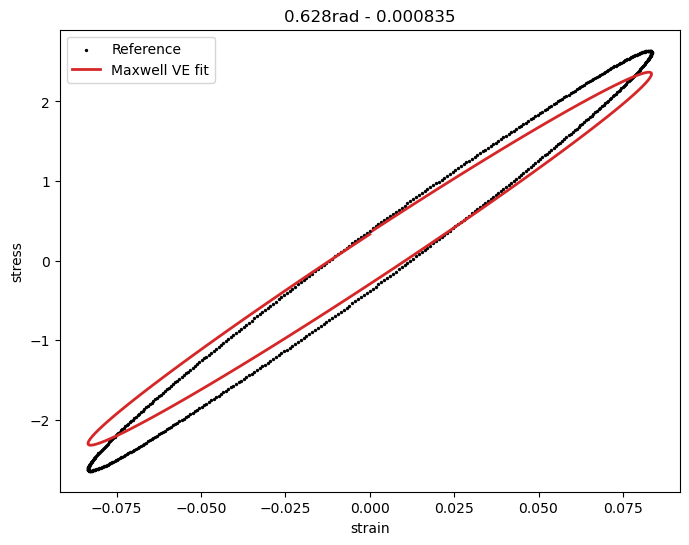

0.628rad - 0.0027183


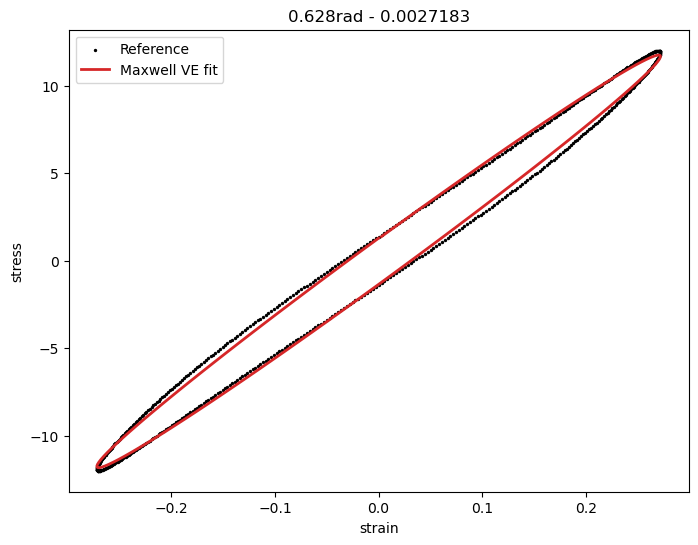

0.628rad - 0.0079461


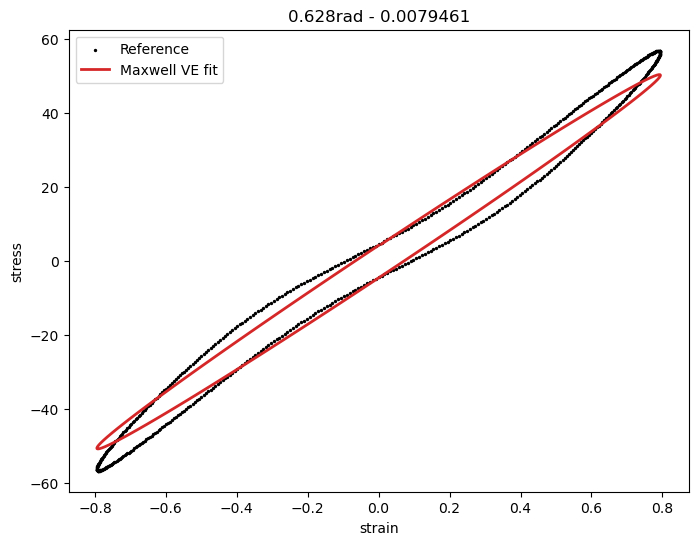

0.628rad - 0.0583731


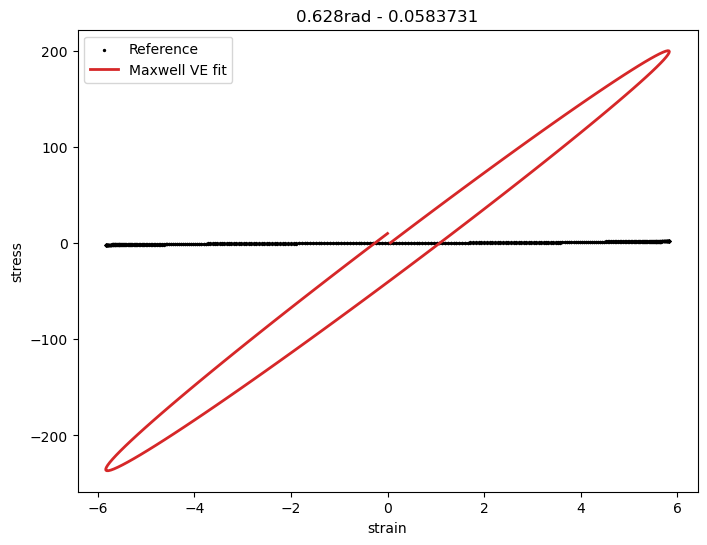

0.628rad - 7.83e-05


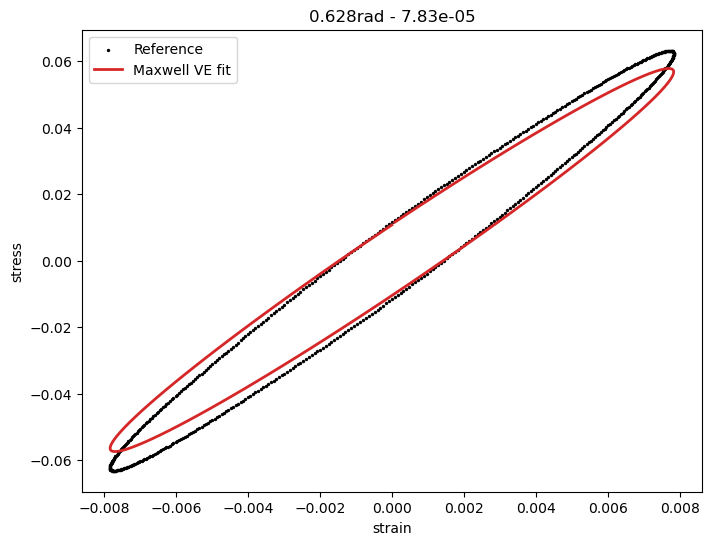

0.628rad - 0.0002521


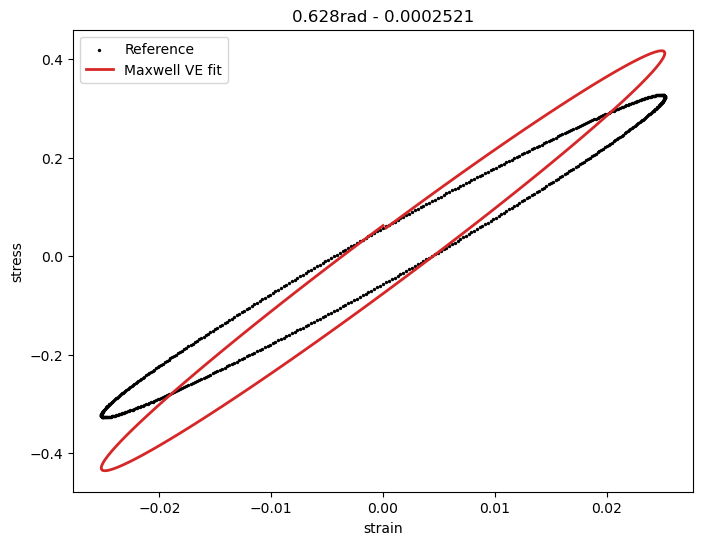

0.628rad - 0.0008682


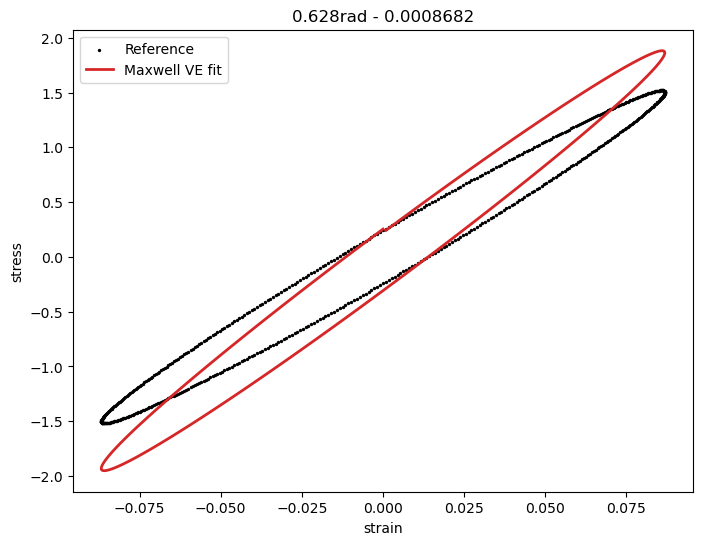

0.628rad - 0.0027884


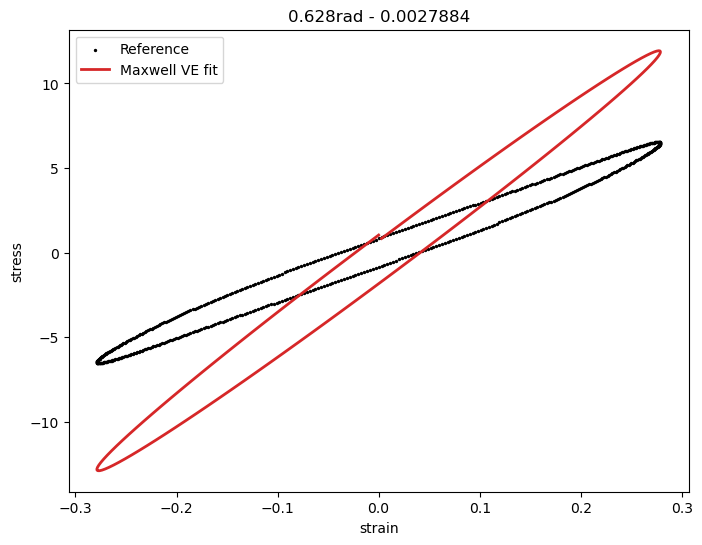

0.628rad - 0.0075938


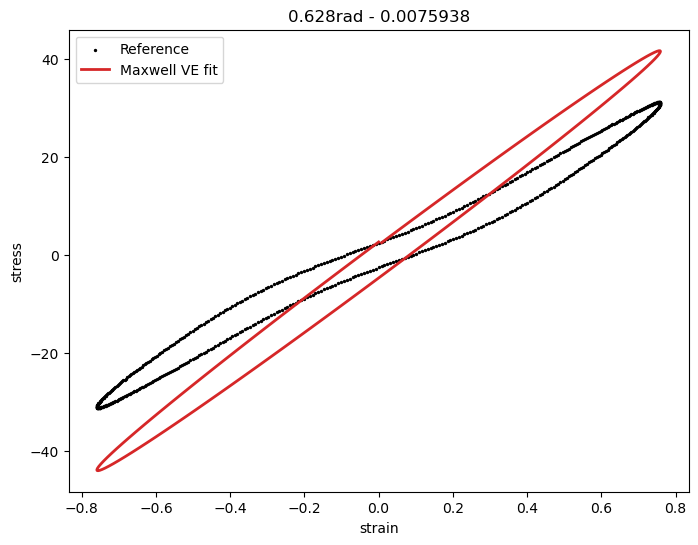

0.628rad - 0.041893


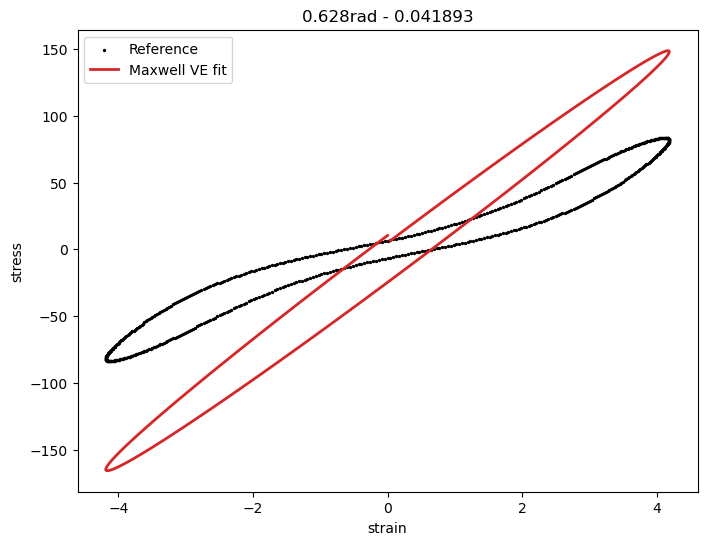

In [20]:
y000 = y0_fit
g00 = x_fit[:,1]
omega0 = x_fit[:,0]
lf_set = indices
N_exp = int(10.*len(s_hf_sampled)/len(lf_set))

g0_exp, t_exp, w_exp = np.array([]), np.array([]), np.array([])
g_exp, gdot_exp, s_exp = np.array([]), np.array([]), np.array([])

for i in lf_set:

    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)

    omega = omega0[i]
    g0 = g00[i]
    y0 = y000[i]
    
    x_pred = np.reshape([omega, g0], (1,-1))
    eta_pred, tau_pred = rf_regressor.predict(x_pred)[0]

    t_pred = np.linspace(min(t_test), max(t_test), N_exp)
    y_pred = fit_function(t_pred, eta_pred, tau_pred)
    
    g_pred = g0 * np.sin(omega * t_pred)
    gdot_pred = g0*omega*np.cos(omega * t_pred) /100.
    
    #LF generation
    g0_exp = np.append(g0_exp, g0*np.ones(N_exp))
    t_exp = np.append(t_exp, t_pred)
    w_exp = np.append(w_exp, omega*np.ones(N_exp))
    
    g_exp = np.append(g_exp, g_pred)
    gdot_exp = np.append(gdot_exp, gdot_pred)
    s_exp = np.append(s_exp, y_pred)

    plt.figure(figsize=(8, 6))
    plt.title(data[i][0]) # Added title here
    plt.scatter(st_test * 100, s_test, label='Reference', s=2, color='k')
    plt.plot(g_pred, y_pred, label='Maxwell VE fit', color='tab:red', lw=2)
    plt.xlabel('strain')
    plt.ylabel('stress')
    plt.legend()
    plt.show()


### Exporting the Lo-Fi and Hi-Fi SAOS data
As mentioned above, and due to the time shift, the Hi-Fi data is also generated here based on the raw Hi-Fi data.

In [21]:
df_LF_raw = np.column_stack([g0_exp, t_exp, w_exp, g_exp, gdot_exp, s_exp])
df_LF = pd.DataFrame(df_LF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_LF.to_excel("Data_LF_SAOS.xlsx", index=False)
df_HF_raw = np.column_stack([g0_hf_sampled, t_hf_sampled,
                             w_hf_sampled, g_hf_sampled,
                             gdot_hf_sampled, s_hf_sampled])
df_HF = pd.DataFrame(df_HF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_HF.to_excel("Data_HF_SAOS.xlsx", index=False)